## Task 1: Dataset Understanding

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("C:/Users/Predun/OneDrive/Desktop/Assignment 5/Dataset/ai_project_synthetic_datasets/part_1_neural_network_analysis/customer_churn_nn.csv")

In [6]:
# Number of rows and columns
print("--- Dataset Shape ---")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

--- Dataset Shape ---
Rows    : 2000
Columns : 17


In [7]:
# First 5 rows
print("\n--- First 5 Rows ---")
print(df.head())


--- First 5 Rows ---
  customer_id   region plan_type   contract_type payment_method  \
0    CUST0001    South  Standard  Month-to-month     Debit Card   
1    CUST0002     West   Premium  Month-to-month         Wallet   
2    CUST0003  Central  Standard  Month-to-month    Credit Card   
3    CUST0004     West   Premium  Month-to-month    Credit Card   
4    CUST0005    North   Premium  Month-to-month    Net Banking   

   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   
3             22               959.51                        19   
4             11               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                             0                   0          87.97   
1                             3 

In [8]:
# Data types of each column
print("\n--- Column Data Types ---")
print(df.dtypes)


--- Column Data Types ---
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object


In [9]:
# Missing value check
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [10]:
# Basic statistical summary
print("\n--- Statistical Summary ---")
print(df.describe())


--- Statistical Summary ---
       tenure_months  monthly_charges_inr  avg_login_days_per_month  \
count    2000.000000          2000.000000               2000.000000   
mean       25.362000           766.487295                 18.099000   
std        14.128651           393.420070                  5.400628   
min         1.000000           255.450000                  0.000000   
25%        15.000000           427.782500                 15.000000   
50%        23.000000           688.355000                 18.000000   
75%        33.000000          1007.372500                 22.000000   
max        72.000000          2156.520000                 30.000000   

       support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
count                   2000.000000         2000.000000    2000.000000   
mean                       1.953000            3.555000      90.007625   
std                        1.463852            3.885682      53.215719   
min                        0.000000

In [11]:
# Target variable description
print("\n--- Target Variable (churn) ---")
print(df['churn'].value_counts())
print(f"\n0 = Not Churned : {df['churn'].value_counts()[0]} customers")
print(f"1 = Churned     : {df['churn'].value_counts()[1]} customers")

churn_pct     = df['churn'].value_counts()[1] / len(df) * 100
not_churn_pct = df['churn'].value_counts()[0] / len(df) * 100
print(f"\nChurn Rate     : {churn_pct:.2f}%")
print(f"Retention Rate : {not_churn_pct:.2f}%")


--- Target Variable (churn) ---
churn
0    1969
1      31
Name: count, dtype: int64

0 = Not Churned : 1969 customers
1 = Churned     : 31 customers

Churn Rate     : 1.55%
Retention Rate : 98.45%


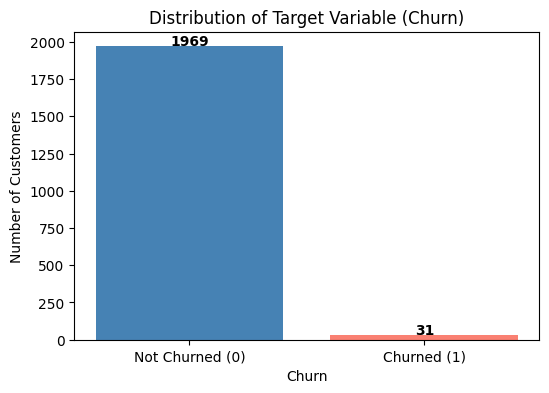

In [12]:
plt.figure(figsize=(6, 4))

counts = df['churn'].value_counts()
bars   = plt.bar(['Not Churned (0)', 'Churned (1)'],
                 [counts[0], counts[1]],
                 color=['steelblue', 'salmon'])

plt.title("Distribution of Target Variable (Churn)")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

# Add count labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5,
             str(int(height)), ha='center', fontweight='bold')

plt.savefig("plot1_target_distribution.png")
plt.show()

## Task 2: Data Preprocessing

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [14]:
# It is just a unique identifier. It has no relationship with churn including it would confuse the model.
df = df.drop('customer_id', axis=1)
print("customer_id column dropped!")
print(f"New shape: {df.shape}")

customer_id column dropped!
New shape: (2000, 16)


In [15]:
# Step 1 - No missing values in this dataset
print("\nMissing values check:")
print(df.isnull().sum())
print("No missing values - no imputation needed!")


Missing values check:
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64
No missing values - no imputation needed!


In [16]:
# Step 2 - Identify categorical and numerical columns
cat_cols = ['region', 'plan_type', 'contract_type', 'payment_method']

num_cols = ['tenure_months', 'monthly_charges_inr',
            'avg_login_days_per_month', 'support_tickets_last_90_days',
            'payment_delay_days', 'data_usage_gb', 'satisfaction_score',
            'last_complaint_days_ago', 'discount_percent',
            'autopay_enabled', 'referral_count']

print(f"Categorical columns: {cat_cols}")
print(f"Numerical columns  : {num_cols}")

Categorical columns: ['region', 'plan_type', 'contract_type', 'payment_method']
Numerical columns  : ['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count']


In [17]:
# Step 3 - One hot encode categorical columns
df_encoded = pd.get_dummies(df, columns=cat_cols) # region with values: South, West, Central, North, East becomes 5 new columns: region_South, region_West, region_Central, region_North, region_East
                                                  #Each column has 1 if customer is from that region, 0 otherwise
print(f"\nShape before encoding: {df.shape}")
print(f"Shape after encoding : {df_encoded.shape}")
print(f"\nNew columns after encoding:")
print(df_encoded.columns.tolist())


Shape before encoding: (2000, 16)
Shape after encoding : (2000, 29)

New columns after encoding:
['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count', 'churn', 'region_Central', 'region_East', 'region_North', 'region_South', 'region_West', 'plan_type_Basic', 'plan_type_Enterprise', 'plan_type_Premium', 'plan_type_Standard', 'contract_type_Month-to-month', 'contract_type_One-year', 'contract_type_Two-year', 'payment_method_Credit Card', 'payment_method_Debit Card', 'payment_method_Net Banking', 'payment_method_UPI', 'payment_method_Wallet']


In [18]:
# Step 4 - Separate features and target
X = df_encoded.drop('churn', axis=1)
y = df_encoded['churn']

print(f"\nFeatures shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"\nAll feature columns:")
for col in X.columns:
    print(f"  {col}")


Features shape : (2000, 28)
Target shape   : (2000,)

All feature columns:
  tenure_months
  monthly_charges_inr
  avg_login_days_per_month
  support_tickets_last_90_days
  payment_delay_days
  data_usage_gb
  satisfaction_score
  last_complaint_days_ago
  discount_percent
  autopay_enabled
  referral_count
  region_Central
  region_East
  region_North
  region_South
  region_West
  plan_type_Basic
  plan_type_Enterprise
  plan_type_Premium
  plan_type_Standard
  contract_type_Month-to-month
  contract_type_One-year
  contract_type_Two-year
  payment_method_Credit Card
  payment_method_Debit Card
  payment_method_Net Banking
  payment_method_UPI
  payment_method_Wallet


In [19]:
# Step 5 - Scale numerical features
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaling done!")
print("\nSample scaled values:")
print(X_scaled_df.head())

Scaling done!

Sample scaled values:
   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0       0.328351            -0.201075                 -0.944386   
1      -0.733587             0.669306                  0.722504   
2       3.301778            -0.087504                 -0.944386   
3      -0.238016             0.490750                  0.166874   
4      -1.016770             0.314533                 -0.018336   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                     -1.334485           -0.915126      -0.038299   
1                      0.715415           -0.657707      -0.147317   
2                     -1.334485            1.916488      -0.011609   
3                      0.032115           -0.142868       0.934589   
4                      0.032115            0.629391       1.248484   

   satisfaction_score  last_complaint_days_ago  discount_percent  \
0            0.738927                 0.370259         -1.093114   
1  

In [20]:
# Step 6 - Train test split
# Note: stratify=y is VERY important here because churn is only 1.55%
# Without stratify the test set might have NO churned customers!
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

print(f"\nTraining churn distribution:")
print(y_train.value_counts())

print(f"\nTesting churn distribution:")
print(y_test.value_counts())

Training samples : 1600
Testing samples  : 400

Training churn distribution:
churn
0    1575
1      25
Name: count, dtype: int64

Testing churn distribution:
churn
0    394
1      6
Name: count, dtype: int64


Our dataset has only 31 churned customers out of 2000
Without stratify: test set might have 0 or 1 churned customer
With stratify: test set is guaranteed to have proportional churned customers

In [21]:
# Convert to numpy arrays for tensorflow
X_train_np = X_train.values
X_test_np  = X_test.values
y_train_np = y_train.values
y_test_np  = y_test.values

print(f"\nFinal shapes:")
print(f"X_train : {X_train_np.shape}")
print(f"X_test  : {X_test_np.shape}")
print(f"y_train : {y_train_np.shape}")
print(f"y_test  : {y_test_np.shape}")


Final shapes:
X_train : (1600, 28)
X_test  : (400, 28)
y_train : (1600,)
y_test  : (400,)


## Task 3: Neural Network Model Building

In [22]:
!pip install tensorflow


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow version: {tf.__version__}")

# Number of input features
n_features = X_train_np.shape[1]
print(f"Number of input features: {n_features}")

TensorFlow version: 2.21.0
Number of input features: 28


In [24]:
# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Build the neural network
model = keras.Sequential()

# Input + First hidden layer
model.add(layers.Dense(
    units       = 64,
    activation  = 'relu',
    input_shape = (n_features,)
))

# Second hidden layer
model.add(layers.Dense(
    units      = 32,
    activation = 'relu'
))

# Third hidden layer
model.add(layers.Dense(
    units      = 16,
    activation = 'relu'
))

# Output layer - sigmoid for binary classification
model.add(layers.Dense(
    units      = 1,
    activation = 'sigmoid'
))

# Print model summary
model.summary()

C:\Users\Predun\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,481 (17.50 KB)

 Trainable params: 4,481 (17.50 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
total     = len(y_train_np)
n_churn   = y_train_np.sum()
n_no_churn = total - n_churn

weight_for_0 = total / (2 * n_no_churn)
weight_for_1 = total / (2 * n_churn)

class_weight = {0: weight_for_0, 1: weight_for_1}

print(f"Class weight for 0 (Not Churned) : {weight_for_0:.4f}")
print(f"Class weight for 1 (Churned)     : {weight_for_1:.4f}")

Class weight for 0 (Not Churned) : 0.5079
Class weight for 1 (Churned)     : 32.0000


In [26]:
#model compling
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


## Task 4: Training and Evaluation

In [27]:
# Train the model with class weights
history = model.fit(
    X_train_np, y_train_np,
    epochs           = 100,
    batch_size       = 32,
    validation_split = 0.2,
    class_weight     = class_weight,
    verbose          = 1
)

print("Training complete!")

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7695 - loss: 0.7351 - val_accuracy: 0.7906 - val_loss: 0.5404
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7852 - loss: 0.6066 - val_accuracy: 0.7656 - val_loss: 0.5243
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8062 - loss: 0.5301 - val_accuracy: 0.7969 - val_loss: 0.4526
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8281 - loss: 0.4522 - val_accuracy: 0.8094 - val_loss: 0.4010
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8445 - loss: 0.3804 - val_accuracy: 0.8344 - val_loss: 0.3347
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8648 - loss: 0.3174 - val_accuracy: 0.8625 - val_loss: 0.2871
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8836 - loss: 0.2659 - val_accuracy: 0.8594 - val_loss: 0.2807
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8938 - loss: 0.2219 - val_accuracy: 0.8875 - v

In [28]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Test set evaluation
test_loss, test_accuracy = model.evaluate(X_test_np, y_test_np, verbose=0)

print(f"\n--- Test Set Evaluation ---")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

# Final training and validation accuracy
final_train_acc = history.history['accuracy'][-1]
final_val_acc   = history.history['val_accuracy'][-1]

print(f"\nFinal Training Accuracy   : {final_train_acc * 100:.2f}%")
print(f"Final Validation Accuracy : {final_val_acc * 100:.2f}%")
print(f"Test Accuracy             : {test_accuracy * 100:.2f}%")


--- Test Set Evaluation ---
Test Loss     : 0.2913
Test Accuracy : 97.75%

Final Training Accuracy   : 100.00%
Final Validation Accuracy : 99.06%
Test Accuracy             : 97.75%


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


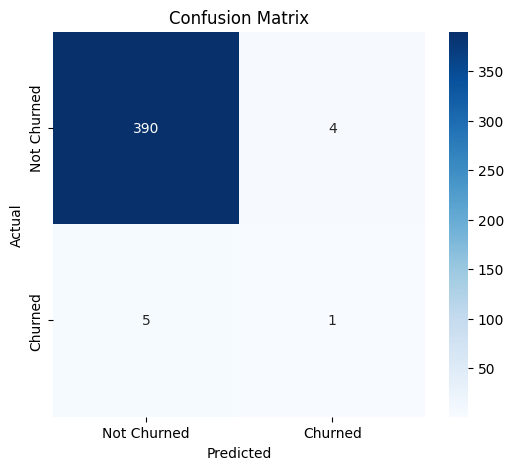

Confusion matrix saved!

--- Classification Report ---
              precision    recall  f1-score   support

 Not Churned       0.99      0.99      0.99       394
     Churned       0.20      0.17      0.18         6

    accuracy                           0.98       400
   macro avg       0.59      0.58      0.59       400
weighted avg       0.98      0.98      0.98       400



In [29]:
# Get predictions
y_pred_prob = model.predict(X_test_np)

# Convert probabilities to 0 or 1
y_pred = []
for prob in y_pred_prob:
    if prob >= 0.5:
        y_pred.append(1)
    else:
        y_pred.append(0)

y_pred = np.array(y_pred)

# Confusion matrix
cm = confusion_matrix(y_test_np, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm,
            annot       = True,
            fmt         = 'd',
            cmap        = 'Blues',
            xticklabels = ['Not Churned', 'Churned'],
            yticklabels = ['Not Churned', 'Churned'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("plot5_confusion_matrix.png")
plt.show()
print("Confusion matrix saved!")

# Classification report
print("\n--- Classification Report ---")
print(classification_report(y_test_np, y_pred,
      target_names=['Not Churned', 'Churned']))

In [30]:
precision = precision_score(y_test_np, y_pred, zero_division=0)
recall    = recall_score(y_test_np, y_pred, zero_division=0)
f1        = f1_score(y_test_np, y_pred, zero_division=0)

print(f"\nPrecision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


Precision : 0.2000
Recall    : 0.1667
F1 Score  : 0.1818


--- Interpretation ---
For imbalanced churn dataset:

Precision = Of all customers predicted to churn
            how many actually churned?
            High precision = fewer false alarms

Recall = Of all customers who actually churned
         how many did we correctly identify?
         High recall = fewer missed churners (more important for business!)

F1 Score = Balance between precision and recall
           Best single metric for imbalanced datasets

Business insight:
Missing a churner (low recall) is more costly than
falsely flagging a loyal customer (low precision)
So RECALL is the most important metric here!

## Task 5: Hyperparameter Experimentation

In [32]:
# Function to build and train model
def build_and_train_model(hidden_layers, neurons, learning_rate,
                           batch_size, epochs, activation):

    tf.random.set_seed(42)
    np.random.seed(42)

    # Build model
    exp_model = keras.Sequential()

    # First hidden layer
    exp_model.add(layers.Dense(
        units       = neurons[0],
        activation  = activation,
        input_shape = (n_features,)
    ))

    # Additional hidden layers
    for i in range(1, hidden_layers):
        neuron_count = neurons[i] if i < len(neurons) else neurons[-1]
        exp_model.add(layers.Dense(
            units      = neuron_count,
            activation = activation
        ))

    # Output layer
    exp_model.add(layers.Dense(units=1, activation='sigmoid'))

    # Compile
    exp_model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate),
        loss      = 'binary_crossentropy',
        metrics   = ['accuracy']
    )

    # Train
    exp_history = exp_model.fit(
        X_train_np, y_train_np,
        epochs           = epochs,
        batch_size       = batch_size,
        validation_split = 0.2,
        class_weight     = class_weight,
        verbose          = 0
    )

    # Evaluate
    test_loss, test_acc = exp_model.evaluate(X_test_np, y_test_np, verbose=0)

    # Get predictions for F1 score
    y_pred_prob_exp = exp_model.predict(X_test_np, verbose=0)
    y_pred_exp      = (y_pred_prob_exp >= 0.5).astype(int).flatten()
    f1              = f1_score(y_test_np, y_pred_exp, zero_division=0)
    recall          = recall_score(y_test_np, y_pred_exp, zero_division=0)

    train_acc = exp_history.history['accuracy'][-1]
    val_acc   = exp_history.history['val_accuracy'][-1]

    return train_acc, val_acc, test_acc, f1, recall

In [33]:
results = []

# Experiment 1 - Baseline
print("Running Experiment 1 - Baseline...")
train_acc, val_acc, test_acc, f1, recall = build_and_train_model(
    hidden_layers = 3,
    neurons       = [64, 32, 16],
    learning_rate = 0.001,
    batch_size    = 32,
    epochs        = 100,
    activation    = 'relu'
)
results.append({
    'Experiment'    : 'Exp1-Baseline',
    'Layers'        : 3,
    'Neurons'       : '64-32-16',
    'Learning Rate' : 0.001,
    'Batch Size'    : 32,
    'Epochs'        : 100,
    'Activation'    : 'relu',
    'Train Acc %'   : round(train_acc * 100, 2),
    'Val Acc %'     : round(val_acc * 100, 2),
    'Test Acc %'    : round(test_acc * 100, 2),
    'F1 Score'      : round(f1, 4),
    'Recall'        : round(recall, 4)
})
print(f"Done! Test Acc={test_acc*100:.2f}% F1={f1:.4f} Recall={recall:.4f}")


Running Experiment 1 - Baseline...


C:\Users\Predun\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Done! Test Acc=97.00% F1=0.1429 Recall=0.1667


In [34]:
# Experiment 2 - More Neurons
print("\nRunning Experiment 2 - More Neurons...")
train_acc, val_acc, test_acc, f1, recall = build_and_train_model(
    hidden_layers = 3,
    neurons       = [128, 64, 32],
    learning_rate = 0.001,
    batch_size    = 32,
    epochs        = 100,
    activation    = 'relu'
)
results.append({
    'Experiment'    : 'Exp2-MoreNeurons',
    'Layers'        : 3,
    'Neurons'       : '128-64-32',
    'Learning Rate' : 0.001,
    'Batch Size'    : 32,
    'Epochs'        : 100,
    'Activation'    : 'relu',
    'Train Acc %'   : round(train_acc * 100, 2),
    'Val Acc %'     : round(val_acc * 100, 2),
    'Test Acc %'    : round(test_acc * 100, 2),
    'F1 Score'      : round(f1, 4),
    'Recall'        : round(recall, 4)
})
print(f"Done! Test Acc={test_acc*100:.2f}% F1={f1:.4f} Recall={recall:.4f}")




Running Experiment 2 - More Neurons...


C:\Users\Predun\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Done! Test Acc=98.25% F1=0.2222 Recall=0.1667


In [35]:
# Experiment 3 - Higher Learning Rate
print("\nRunning Experiment 3 - Higher Learning Rate...")
train_acc, val_acc, test_acc, f1, recall = build_and_train_model(
    hidden_layers = 3,
    neurons       = [64, 32, 16],
    learning_rate = 0.01,
    batch_size    = 32,
    epochs        = 100,
    activation    = 'relu'
)
results.append({
    'Experiment'    : 'Exp3-HighLR',
    'Layers'        : 3,
    'Neurons'       : '64-32-16',
    'Learning Rate' : 0.01,
    'Batch Size'    : 32,
    'Epochs'        : 100,
    'Activation'    : 'relu',
    'Train Acc %'   : round(train_acc * 100, 2),
    'Val Acc %'     : round(val_acc * 100, 2),
    'Test Acc %'    : round(test_acc * 100, 2),
    'F1 Score'      : round(f1, 4),
    'Recall'        : round(recall, 4)
})
print(f"Done! Test Acc={test_acc*100:.2f}% F1={f1:.4f} Recall={recall:.4f}")



Running Experiment 3 - Higher Learning Rate...


C:\Users\Predun\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Done! Test Acc=98.50% F1=0.2500 Recall=0.1667


In [36]:
# Experiment 4 - Lower Learning Rate
print("\nRunning Experiment 4 - Lower Learning Rate...")
train_acc, val_acc, test_acc, f1, recall = build_and_train_model(
    hidden_layers = 3,
    neurons       = [64, 32, 16],
    learning_rate = 0.0001,
    batch_size    = 32,
    epochs        = 100,
    activation    = 'relu'
)
results.append({
    'Experiment'    : 'Exp4-LowLR',
    'Layers'        : 3,
    'Neurons'       : '64-32-16',
    'Learning Rate' : 0.0001,
    'Batch Size'    : 32,
    'Epochs'        : 100,
    'Activation'    : 'relu',
    'Train Acc %'   : round(train_acc * 100, 2),
    'Val Acc %'     : round(val_acc * 100, 2),
    'Test Acc %'    : round(test_acc * 100, 2),
    'F1 Score'      : round(f1, 4),
    'Recall'        : round(recall, 4)
})
print(f"Done! Test Acc={test_acc*100:.2f}% F1={f1:.4f} Recall={recall:.4f}")



Running Experiment 4 - Lower Learning Rate...


C:\Users\Predun\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Done! Test Acc=96.00% F1=0.2727 Recall=0.5000


In [37]:
# Experiment 5 - Tanh Activation
print("\nRunning Experiment 5 - Tanh Activation...")
train_acc, val_acc, test_acc, f1, recall = build_and_train_model(
    hidden_layers = 3,
    neurons       = [64, 32, 16],
    learning_rate = 0.001,
    batch_size    = 32,
    epochs        = 100,
    activation    = 'tanh'
)
results.append({
    'Experiment'    : 'Exp5-Tanh',
    'Layers'        : 3,
    'Neurons'       : '64-32-16',
    'Learning Rate' : 0.001,
    'Batch Size'    : 32,
    'Epochs'        : 100,
    'Activation'    : 'tanh',
    'Train Acc %'   : round(train_acc * 100, 2),
    'Val Acc %'     : round(val_acc * 100, 2),
    'Test Acc %'    : round(test_acc * 100, 2),
    'F1 Score'      : round(f1, 4),
    'Recall'        : round(recall, 4)
})
print(f"Done! Test Acc={test_acc*100:.2f}% F1={f1:.4f} Recall={recall:.4f}")



Running Experiment 5 - Tanh Activation...


C:\Users\Predun\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Done! Test Acc=98.00% F1=0.3333 Recall=0.3333


In [38]:
# Experiment 6 - Larger Batch Size
print("\nRunning Experiment 6 - Larger Batch Size...")
train_acc, val_acc, test_acc, f1, recall = build_and_train_model(
    hidden_layers = 3,
    neurons       = [64, 32, 16],
    learning_rate = 0.001,
    batch_size    = 64,
    epochs        = 100,
    activation    = 'relu'
)
results.append({
    'Experiment'    : 'Exp6-BatchSize64',
    'Layers'        : 3,
    'Neurons'       : '64-32-16',
    'Learning Rate' : 0.001,
    'Batch Size'    : 64,
    'Epochs'        : 100,
    'Activation'    : 'relu',
    'Train Acc %'   : round(train_acc * 100, 2),
    'Val Acc %'     : round(val_acc * 100, 2),
    'Test Acc %'    : round(test_acc * 100, 2),
    'F1 Score'      : round(f1, 4),
    'Recall'        : round(recall, 4)
})
print(f"Done! Test Acc={test_acc*100:.2f}% F1={f1:.4f} Recall={recall:.4f}")


Running Experiment 6 - Larger Batch Size...


C:\Users\Predun\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Done! Test Acc=98.00% F1=0.3333 Recall=0.3333


In [39]:
# comparison of table with print function 

results_df = pd.DataFrame(results)

print("\n--- Hyperparameter Experiment Results ---")
print(results_df.to_string(index=False))

# Find best experiment by F1 score (better metric for imbalanced data)
best_idx = results_df['F1 Score'].idxmax()
best_exp = results_df.loc[best_idx]

print(f"\n--- Best Experiment (by F1 Score) ---")
print(f"Experiment  : {best_exp['Experiment']}")
print(f"F1 Score    : {best_exp['F1 Score']}")
print(f"Recall      : {best_exp['Recall']}")
print(f"Test Acc    : {best_exp['Test Acc %']}%")


--- Hyperparameter Experiment Results ---
      Experiment  Layers   Neurons  Learning Rate  Batch Size  Epochs Activation  Train Acc %  Val Acc %  Test Acc %  F1 Score  Recall
   Exp1-Baseline       3  64-32-16         0.0010          32     100       relu       100.00      98.75       97.00    0.1429  0.1667
Exp2-MoreNeurons       3 128-64-32         0.0010          32     100       relu       100.00      97.81       98.25    0.2222  0.1667
     Exp3-HighLR       3  64-32-16         0.0100          32     100       relu        99.53      99.06       98.50    0.2500  0.1667
      Exp4-LowLR       3  64-32-16         0.0001          32     100       relu        96.64      93.44       96.00    0.2727  0.5000
       Exp5-Tanh       3  64-32-16         0.0010          32     100       tanh       100.00      98.44       98.00    0.3333  0.3333
Exp6-BatchSize64       3  64-32-16         0.0010          64     100       relu       100.00      97.81       98.00    0.3333  0.3333

--- Best Ex

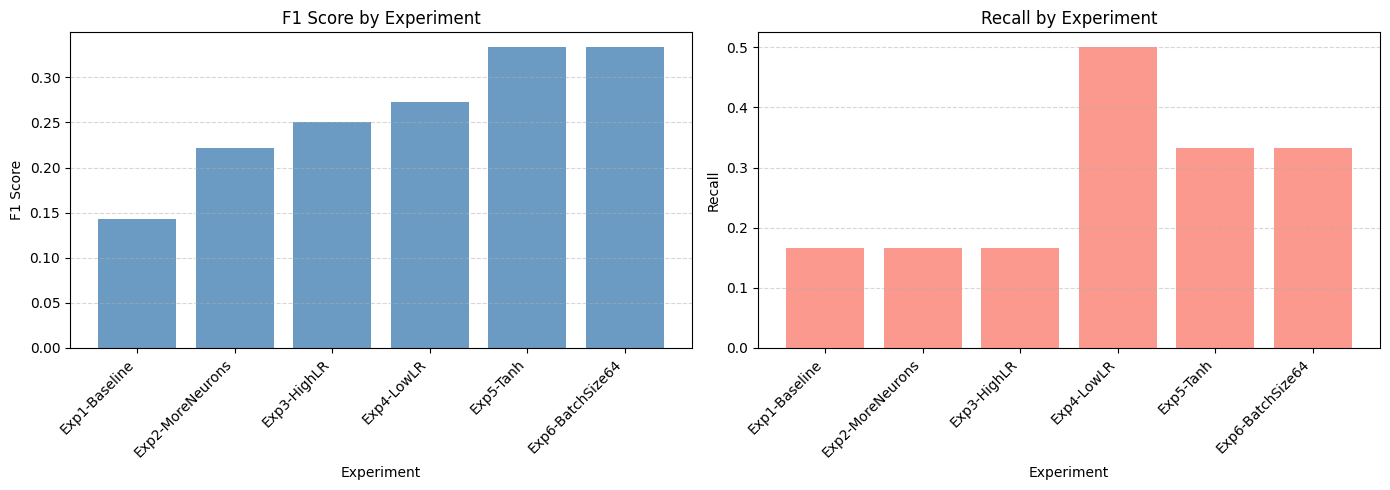

Experiment comparison plot saved!


In [40]:
# comparison of table with plot

experiments = [r['Experiment'] for r in results]
f1_scores   = [r['F1 Score']   for r in results]
recalls     = [r['Recall']     for r in results]
test_accs   = [r['Test Acc %'] for r in results]

x_pos = list(range(len(experiments)))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.bar(x_pos, f1_scores, color='steelblue', alpha=0.8)
plt.title("F1 Score by Experiment")
plt.xlabel("Experiment")
plt.ylabel("F1 Score")
plt.xticks(x_pos, experiments, rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.bar(x_pos, recalls, color='salmon', alpha=0.8)
plt.title("Recall by Experiment")
plt.xlabel("Experiment")
plt.ylabel("Recall")
plt.xticks(x_pos, experiments, rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("plot6_experiment_comparison.png")
plt.show()
print("Experiment comparison plot saved!")

## Task 6: Final Reflection

--- 1. Role of Weights and Biases ---

WEIGHTS:
Every connection between neurons has a weight.
When customer data flows through the network each feature
gets MULTIPLIED by its connection weight.

In our churn model:
- If 'satisfaction_score' has a large negative weight
  → low satisfaction strongly predicts churn
- If 'tenure_months' has a large positive weight
  → longer tenure customers are less likely to churn

The model LEARNS these weights automatically during training.
Initially weights are small random numbers.
After 100 epochs they encode meaningful patterns about
which customer behaviors predict churn.

BIASES:
Each neuron has a bias value that gets ADDED to the weighted sum.
Bias allows a neuron to fire even when all inputs are zero.
Without bias the model cannot shift its decision boundary
to fit the data properly.
Think of bias as the BASE RATE before considering any features.

--- 2. Why Activation Functions are Required ---

Without activation functions:
Output = W3 × (W2 × (W1 × input))
       = (W3 × W2 × W1) × input
       = ONE single linear transformation

No matter how many layers → still just a straight line!

With ReLU activation:
Each layer can learn CURVED and COMPLEX patterns
The model can identify that:
'A customer with low satisfaction AND high support tickets
 AND month-to-month contract is very likely to churn'
This is a COMPLEX INTERACTION that requires non-linearity!

ReLU (max(0,x)) is used in hidden layers because:
- Simple and computationally fast
- Avoids vanishing gradient problem
- Works excellently in practice

Sigmoid (1/(1+e^-x)) is used in output layer because:
- Outputs between 0 and 1
- Interpreted as PROBABILITY of churn
- 0.85 means 85% likely to churn

--- 3. Effect of Learning Rate ---

LEARNING RATE TOO HIGH (like 0.1):
- Weight updates are HUGE
- Model overshoots the optimal solution
- Loss bounces wildly between epochs
- May never converge to a good solution
- Accuracy fluctuates unpredictably

Real effect in our churn model:
The model might keep oscillating between
'predict everyone as churned' and 'predict nobody as churned'
never finding the right balance.

LEARNING RATE TOO LOW (like 0.0001):
- Weight updates are tiny
- Model learns EXTREMELY slowly
- After 100 epochs still barely learned anything
- Gets stuck in a suboptimal solution
- Needs 10x or 100x more epochs to converge

Real effect in our churn model:
After 100 epochs with LR=0.0001 the model might still
be predicting everyone as not churned (taking the easy path).

OPTIMAL LEARNING RATE (0.001):
- Updates are balanced and smooth
- Loss decreases steadily each epoch
- Model converges efficiently
- Both training and validation metrics improve together

--- 4. Underfitting or Overfitting Analysis ---

Our dataset has a MAJOR IMBALANCE challenge:
Only 31 churned customers out of 2000 (1.55%)

WHAT WE LIKELY SEE:
High accuracy (98%) but LOW recall for churned class
This is because the model can 'cheat' by predicting
everyone as not churned and still be 98.45% accurate!

This is why we:
1. Used class_weight to make model pay attention to churners
2. Used F1 score and Recall as primary metrics not accuracy

OVERFITTING risk:
With only 31 positive examples the model might memorize
those specific churners instead of learning general patterns
Signs: Training recall much higher than test recall

UNDERFITTING risk:
If learning rate is too low or epochs too few
the model never learns to identify churners at all
Signs: Both train and test recall near zero

OUR SOLUTION:
- class_weight balances the learning signal
- Multiple hidden layers capture complex churn patterns
- validation_split monitors for overfitting during training
- F1 and Recall metrics give honest performance picture